In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')].copy()
df_DA_US=df_DA_US.dropna(subset='salary_year_avg')

In [3]:
df_DA_US=df_DA_US.explode('job_skills')

In [8]:
df_DA_US_group=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

In [9]:
df_DA_top_pay=df_DA_US_group.sort_values('median',ascending=False).head(10)
df_DA_top_skills=df_DA_US_group.sort_values('count',ascending=False).head(10)

In [ ]:
df_DA_top_skills=df_DA_top_skills.sort_values('median',ascending=True)


job_skills
word          81194.75
excel         84392.00
powerpoint    85000.00
sas           90000.00
power bi      90000.00
sql           91000.00
sql server    92500.00
r             92500.00
tableau       92875.00
python        97500.00
Name: median, dtype: float64

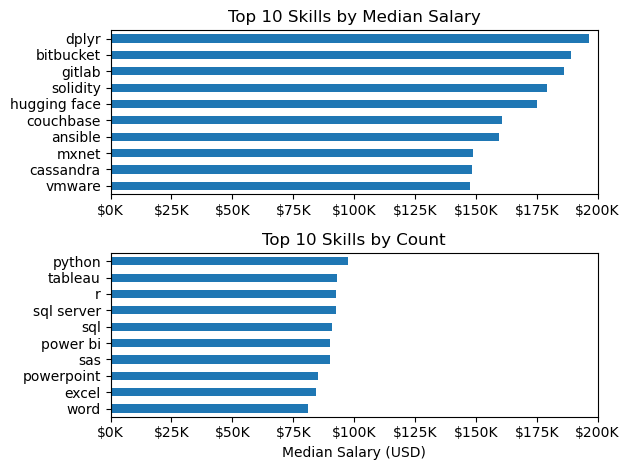

In [40]:
fig, ax=plt.subplots(2,1)
df_DA_top_pay['median'].plot(kind='barh',ax=ax[0],title='Top 10 Skills by Median Salary',legend=False)
ax[0].invert_yaxis()
ax[0].set_xlim(0,200000)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
df_DA_top_skills['median'].plot(kind='barh',ax=ax[1],title='Top 10 Skills by Count',legend=False)
ax[1].set_xlim(0,200000)

ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

In [41]:
import seaborn as sns

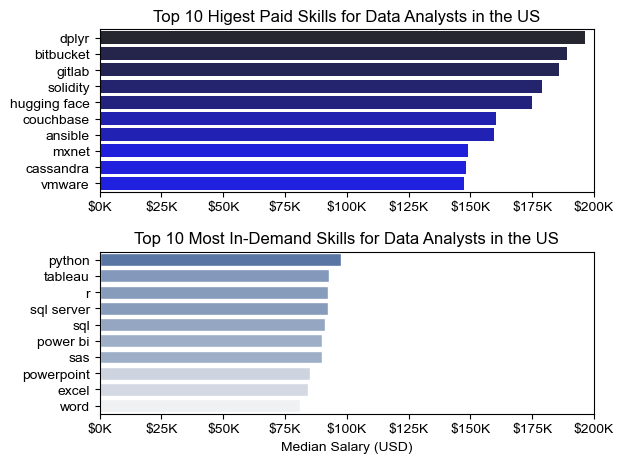

In [49]:
fig, ax=plt.subplots(2,1)
#df_DA_top_pay['median'].plot(kind='barh',ax=ax[0],title='Top 10 Skills by Median Salary',legend=False)
sns.barplot(data=df_DA_top_pay,x=df_DA_top_pay['median'],y=df_DA_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
sns.set_theme(style='ticks')
#ax[0].invert_yaxis()
ax[0].legend_.remove()
ax[0].set_xlim(0,200000)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 Higest Paid Skills for Data Analysts in the US')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
#df_DA_top_skills['median'].plot(kind='barh',ax=ax[1],title='Top 10 Skills by Count',legend=False)
sns.barplot(data=df_DA_top_skills,x=df_DA_top_skills['median'],y=df_DA_top_skills.index,ax=ax[1],hue='median',palette='light:b')
ax[1].legend_.remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts in the US')
ax[1].set_xlim(0,200000)
ax[1].invert_yaxis()
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

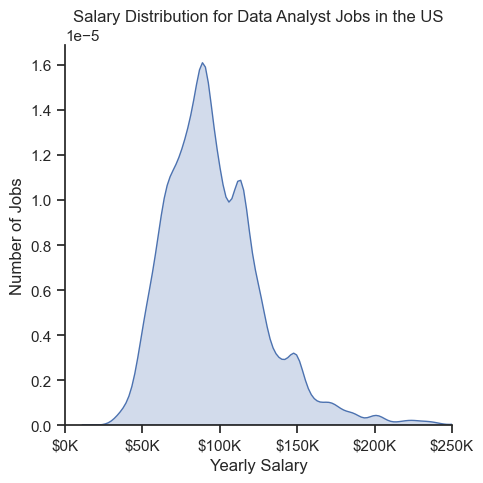

In [53]:
from matplotlib.ticker import FuncFormatter
#ax=df_DA_US['salary_year_avg'].plot(kind='hist',bins=30,edgecolor='black')
sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
plt.xlim(0,250000)
ax=plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Salary Distribution for Data Analyst Jobs in the US')

plt.tight_layout()
plt.show()

C:\Users\sandr\AppData\Local\Temp\ipykernel_26528\54391963.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles,vert=False)


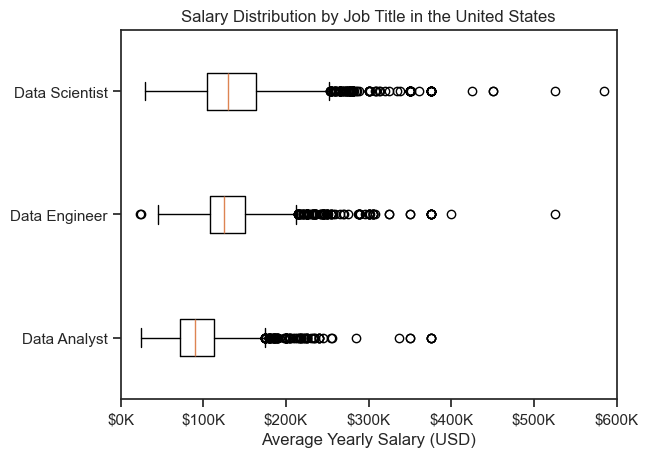

In [54]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']
df_US=df[(df['job_country']=='United States') & (df['job_title_short'].isin(job_titles))].copy()
df_US.dropna(subset='salary_year_avg',inplace=True)
job_list=[df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list,labels=job_titles,vert=False)
plt.title('Salary Distribution by Job Title in the United States')
plt.xlabel('Average Yearly Salary (USD)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, post: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

C:\Users\sandr\AppData\Local\Temp\ipykernel_26528\2941963571.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_US,x='salary_year_avg',y='job_title_short',orient='h',palette='Set2')


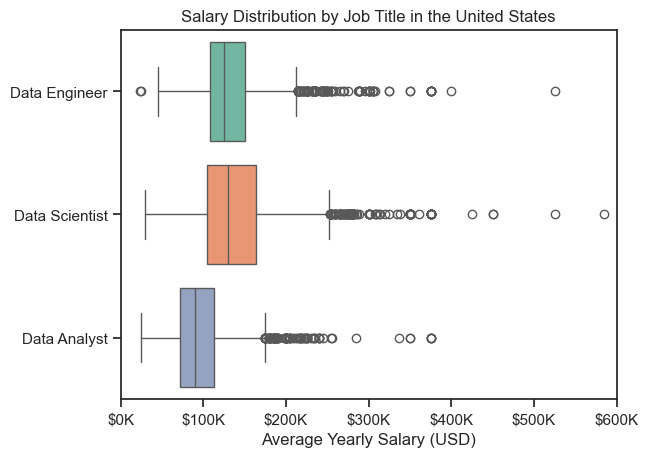

In [56]:
sns.boxplot(data=df_US,x='salary_year_avg',y='job_title_short',orient='h',palette='Set2')
sns.set_theme(style='ticks')

plt.title('Salary Distribution by Job Title in the United States')
plt.xlabel('Average Yearly Salary (USD)')
ax=plt.gca()
plt.ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, post: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()